# Khám phá dữ liệu — dataset.jsonl
Notebook này phân tích cấu trúc và chất lượng tập dữ liệu dịch thuật triết học IEP.

In [1]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

COLAB_ROOT = Path('/content/drive/MyDrive/PhilosophyMT')
if COLAB_ROOT.exists():
    REPO_ROOT = COLAB_ROOT
elif Path.cwd().name == 'notebooks':
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

DATASET_PATH = REPO_ROOT / 'dataset.jsonl'
print(f'Dataset path: {DATASET_PATH}')


Dataset path: e:\PhilosophyMT\dataset.jsonl


## 1. Tải dữ liệu

In [2]:
records = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

# Thêm các cột phân tích
df['en_words']    = df['en'].str.split().str.len()
df['vi_words']    = df['vi'].str.split().str.len()
df['en_chars']    = df['en'].str.len()
df['vi_chars']    = df['vi'].str.len()
df['has_vi']      = df['vi'].str.strip().str.len() > 0
df['ratio_words'] = (df['vi_words'] / df['en_words']).round(3)  # tỉ lệ độ dài vi/en

print(f'Tổng số records  : {len(df):,}')
print(f'Số cột           : {list(df.columns)}')
df.head(3)


Tổng số records  : 4,707
Số cột           : ['id', 'topic', 'en', 'vi', 'en_words', 'vi_words', 'en_chars', 'vi_chars', 'has_vi', 'ratio_words']


,id,topic,en,vi,en_words,vi_words,en_chars,vi_chars,has_vi,ratio_words
0,1,Benedict De Spinoza (1632—1677),Benedict de Spinoza was among the most import...,Benedict de Spinoza là một trong những triết g...,140,214,894,1010,True,1.529
1,2,Benedict De Spinoza (1632—1677),"Among philosophers, Spinoza is best known for ...","Trong giới triết gia, Spinoza được biết đến nh...",99,153,624,701,True,1.545
2,3,Benedict De Spinoza (1632—1677),Humans find happiness only through a rational ...,Con người chỉ tìm thấy hạnh phúc thông qua sự ...,102,159,589,704,True,1.559


## 2. Tổng quan nhanh

In [3]:
total        = len(df)
translated   = df['has_vi'].sum()
missing      = total - translated
num_topics   = df['topic'].nunique()

print('=' * 45)
print(f'  Tổng records          : {total:,}')
print(f'  Đã dịch (vi ≠ "")     : {translated:,}  ({translated/total*100:.1f}%)')
print(f'  Chưa dịch             : {missing:,}  ({missing/total*100:.1f}%)')
print(f'  Số topic (bài viết)   : {num_topics:,}')
print(f'  Trung bình records/topic: {total/num_topics:.1f}')
print('=' * 45)
print()
print('Thống kê độ dài (từ):')
df[['en_words','vi_words','ratio_words']].describe().round(2)


  Tổng records          : 4,707
  Đã dịch (vi ≠ "")     : 4,707  (100.0%)
  Chưa dịch             : 0  (0.0%)
  Số topic (bài viết)   : 37
  Trung bình records/topic: 127.2

Thống kê độ dài (từ):


,en_words,vi_words,ratio_words
count,4707.00,4707.00,4707.00
mean,112.74,162.54,1.44
std,26.00,38.74,0.13
min,50.00,60.00,0.93
25%,96.00,136.50,1.36
50%,115.00,165.00,1.44
75%,132.00,190.50,1.53
max,247.00,329.00,1.96


## 3. Tình trạng dịch thuật

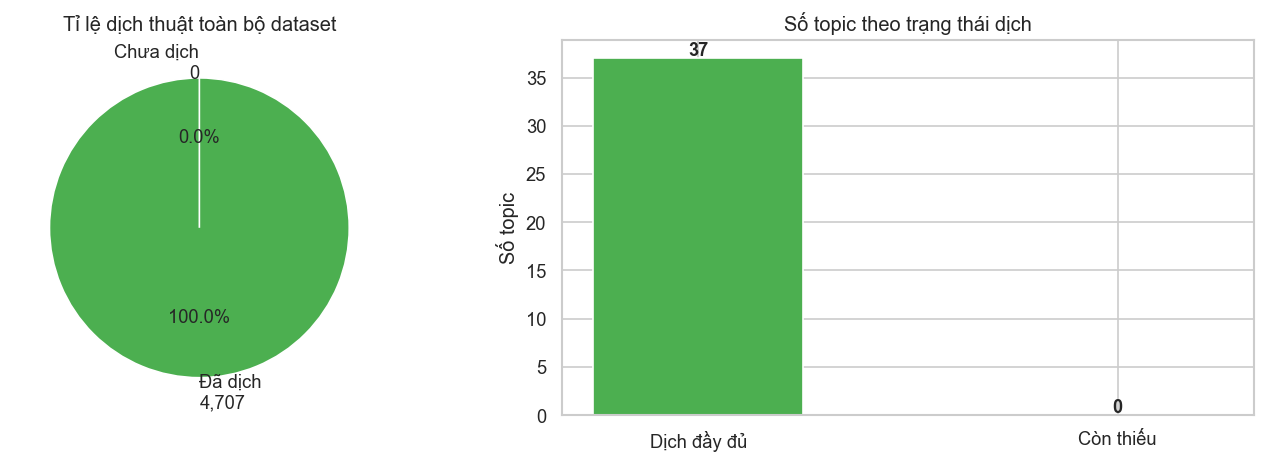

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart tổng thể
labels = [f'Đã dịch\n{translated:,}', f'Chưa dịch\n{missing:,}']
axes[0].pie([translated, missing], labels=labels,
            autopct='%1.1f%%', startangle=90,
            colors=['#4CAF50', '#ef5350'])
axes[0].set_title('Tỉ lệ dịch thuật toàn bộ dataset')

# Theo topic: số topic dịch đầy đủ / còn thiếu
topic_status = df.groupby('topic')['has_vi'].agg(['sum','count'])
topic_status['complete'] = topic_status['sum'] == topic_status['count']
complete_topics   = topic_status['complete'].sum()
incomplete_topics = len(topic_status) - complete_topics

axes[1].bar(['Dịch đầy đủ', 'Còn thiếu'],
            [complete_topics, incomplete_topics],
            color=['#4CAF50', '#ef5350'], width=0.5)
axes[1].set_title('Số topic theo trạng thái dịch')
axes[1].set_ylabel('Số topic')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{int(bar.get_height())}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# In ra các topic còn thiếu bản dịch
if incomplete_topics > 0:
    print('\nCác topic còn record chưa dịch:')
    incomplete = topic_status[~topic_status['complete']].copy()
    incomplete['missing'] = incomplete['count'] - incomplete['sum']
    print(incomplete[['missing','count']].rename(
        columns={'missing':'Chưa dịch','count':'Tổng'}
    ).sort_values('Chưa dịch', ascending=False).to_string())


## 4. Phân phối độ dài đoạn văn (số từ)

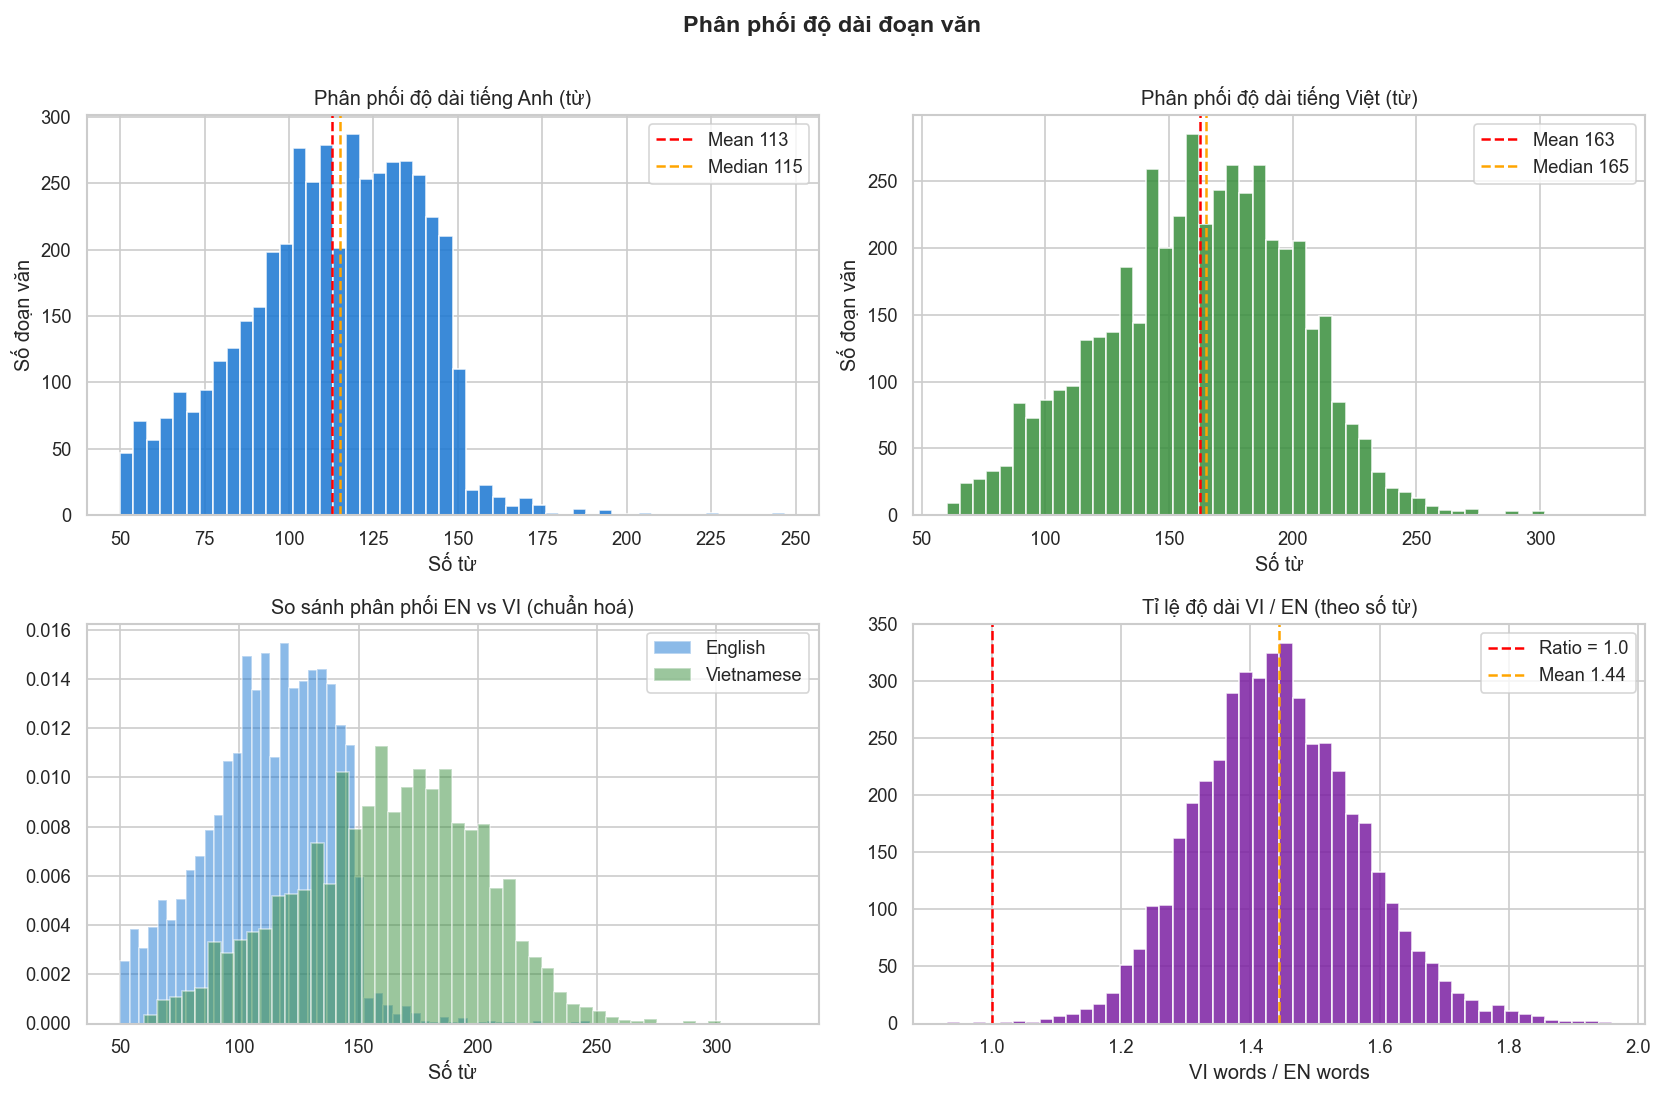


Phân vị độ dài (số từ):


,EN,VI
5%,65.0,94.0
10%,76.0,109.0
25%,96.0,136.5
50%,115.0,165.0
75%,132.0,190.5
90%,144.0,210.0
95%,148.0,221.0


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# EN — histogram
axes[0,0].hist(df['en_words'], bins=50, color='#1976D2', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['en_words'].mean(), color='red', linestyle='--', label=f"Mean {df['en_words'].mean():.0f}")
axes[0,0].axvline(df['en_words'].median(), color='orange', linestyle='--', label=f"Median {df['en_words'].median():.0f}")
axes[0,0].set_title('Phân phối độ dài tiếng Anh (từ)')
axes[0,0].set_xlabel('Số từ')
axes[0,0].set_ylabel('Số đoạn văn')
axes[0,0].legend()

# VI — histogram
vi_df = df[df['has_vi']]
axes[0,1].hist(vi_df['vi_words'], bins=50, color='#388E3C', edgecolor='white', alpha=0.85)
axes[0,1].axvline(vi_df['vi_words'].mean(), color='red', linestyle='--', label=f"Mean {vi_df['vi_words'].mean():.0f}")
axes[0,1].axvline(vi_df['vi_words'].median(), color='orange', linestyle='--', label=f"Median {vi_df['vi_words'].median():.0f}")
axes[0,1].set_title('Phân phối độ dài tiếng Việt (từ)')
axes[0,1].set_xlabel('Số từ')
axes[0,1].set_ylabel('Số đoạn văn')
axes[0,1].legend()

# EN vs VI overlay (KDE)
axes[1,0].hist(df['en_words'], bins=50, alpha=0.5, color='#1976D2', label='English', density=True)
axes[1,0].hist(vi_df['vi_words'], bins=50, alpha=0.5, color='#388E3C', label='Vietnamese', density=True)
axes[1,0].set_title('So sánh phân phối EN vs VI (chuẩn hoá)')
axes[1,0].set_xlabel('Số từ')
axes[1,0].legend()

# Ratio VI/EN
axes[1,1].hist(vi_df['ratio_words'].clip(0, 3), bins=50, color='#7B1FA2', edgecolor='white', alpha=0.85)
axes[1,1].axvline(1.0, color='red', linestyle='--', label='Ratio = 1.0')
axes[1,1].axvline(vi_df['ratio_words'].mean(), color='orange', linestyle='--',
                  label=f"Mean {vi_df['ratio_words'].mean():.2f}")
axes[1,1].set_title('Tỉ lệ độ dài VI / EN (theo số từ)')
axes[1,1].set_xlabel('VI words / EN words')
axes[1,1].legend()

plt.suptitle('Phân phối độ dài đoạn văn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Bảng phân vị
print('\nPhân vị độ dài (số từ):')
pct = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
pd.DataFrame({
    'EN': df['en_words'].quantile(pct).values,
    'VI': vi_df['vi_words'].quantile(pct).values,
}, index=[f'{int(p*100)}%' for p in pct]).round(1)


## 4.1. Phân phối độ dài theo token MarianMT

Đo đúng số token mà `Helsinki-NLP/opus-mt-en-vi` sẽ thấy khi fine-tune: tiếng Anh dùng source tokenizer, tiếng Việt dùng `text_target=...`.


In [6]:
try:
    from transformers import MarianTokenizer
except ImportError:
    raise ImportError('Cần cài transformers trước: pip install transformers sentencepiece')

MARIAN_MODEL_NAME = 'Helsinki-NLP/opus-mt-en-vi'
marian_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL_NAME)
vi_df = df[df['has_vi']].copy()


def count_source_tokens(text: str) -> int:
    return len(marian_tokenizer(text)['input_ids'])


def count_target_tokens(text: str) -> int:
    return len(marian_tokenizer(text_target=text)['input_ids'])


df['en_tokens_marian'] = [count_source_tokens(t) for t in df['en'].tolist()]
vi_token_lengths = [count_target_tokens(t) for t in vi_df['vi'].tolist()]
df.loc[vi_df.index, 'vi_tokens_marian'] = vi_token_lengths

target_series = df.loc[vi_df.index, 'vi_tokens_marian']
summary = pd.DataFrame(
    {
        'EN source tokens': [
            df['en_tokens_marian'].mean(),
            df['en_tokens_marian'].quantile(0.5),
            df['en_tokens_marian'].quantile(0.9),
            df['en_tokens_marian'].quantile(0.95),
            df['en_tokens_marian'].quantile(0.98),
            df['en_tokens_marian'].max(),
        ],
        'VI target tokens': [
            target_series.mean(),
            target_series.quantile(0.5),
            target_series.quantile(0.9),
            target_series.quantile(0.95),
            target_series.quantile(0.98),
            target_series.max(),
        ],
    },
    index=['mean', 'p50', 'p90', 'p95', 'p98', 'max'],
).round(1)

print('Token length summary — Marian tokenizer')
display(summary)

source_candidates = [128, 192, 256, 320, 384, 512]
target_candidates = [256, 320, 384, 448, 512]
source_trunc = pd.DataFrame(
    {
        'max_source_len': source_candidates,
        'truncated_count': [
            (df['en_tokens_marian'] > n).sum() for n in source_candidates
        ],
        'truncated_pct': [
            (df['en_tokens_marian'] > n).mean() * 100 for n in source_candidates
        ],
    }
)
target_trunc = pd.DataFrame(
    {
        'max_target_len': target_candidates,
        'truncated_count': [(target_series > n).sum() for n in target_candidates],
        'truncated_pct': [(target_series > n).mean() * 100 for n in target_candidates],
    }
)

print('\nTruncation risk — source')
display(source_trunc.round({'truncated_pct': 2}))
print('\nTruncation risk — target')
display(target_trunc.round({'truncated_pct': 2}))


def recommend_len(values, candidates, q=0.95, cap=512):
    need = float(pd.Series(values).quantile(q))
    for candidate in candidates:
        if candidate >= need:
            return min(candidate, cap), need
    return min(max(candidates), cap), need


rec_src_p95, src_need_p95 = recommend_len(df['en_tokens_marian'], source_candidates, q=0.95)
rec_tgt_p95, tgt_need_p95 = recommend_len(target_series, target_candidates, q=0.95)
rec_src_p98, src_need_p98 = recommend_len(df['en_tokens_marian'], source_candidates, q=0.98)
rec_tgt_p98, tgt_need_p98 = recommend_len(target_series, target_candidates, q=0.98)

print('\nRecommended Marian max lengths (capped at 512 positional tokens):')
print(
    f'  p95: MAX_SOURCE_LEN={rec_src_p95} (need {src_need_p95:.1f}), '
    f'MAX_TARGET_LEN={rec_tgt_p95} (need {tgt_need_p95:.1f})'
)
print(
    f'  p98: MAX_SOURCE_LEN={rec_src_p98} (need {src_need_p98:.1f}), '
    f'MAX_TARGET_LEN={rec_tgt_p98} (need {tgt_need_p98:.1f})'
)


c:\Users\PhamNguyenAnh\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Token length summary — Marian tokenizer


,EN source tokens,VI target tokens
mean,151.4,188.3
p50,153.0,190.0
p90,197.0,244.0
p95,210.0,257.0
p98,225.9,273.0
max,347.0,374.0



Truncation risk — source


,max_source_len,truncated_count,truncated_pct
0,128,3459,73.49
1,192,588,12.49
2,256,21,0.45
3,320,3,0.06
4,384,0,0.00
5,512,0,0.00



Truncation risk — target


,max_target_len,truncated_count,truncated_pct
0,256,242,5.14
1,320,11,0.23
2,384,0,0.00
3,448,0,0.00
4,512,0,0.00



Recommended Marian max lengths (capped at 512 positional tokens):
  p95: MAX_SOURCE_LEN=256 (need 210.0), MAX_TARGET_LEN=320 (need 257.0)
  p98: MAX_SOURCE_LEN=256 (need 225.9), MAX_TARGET_LEN=320 (need 273.0)


## 5. Phân phối theo topic

Số topic: 37
Records/topic — min: 52, max: 273, mean: 127.2


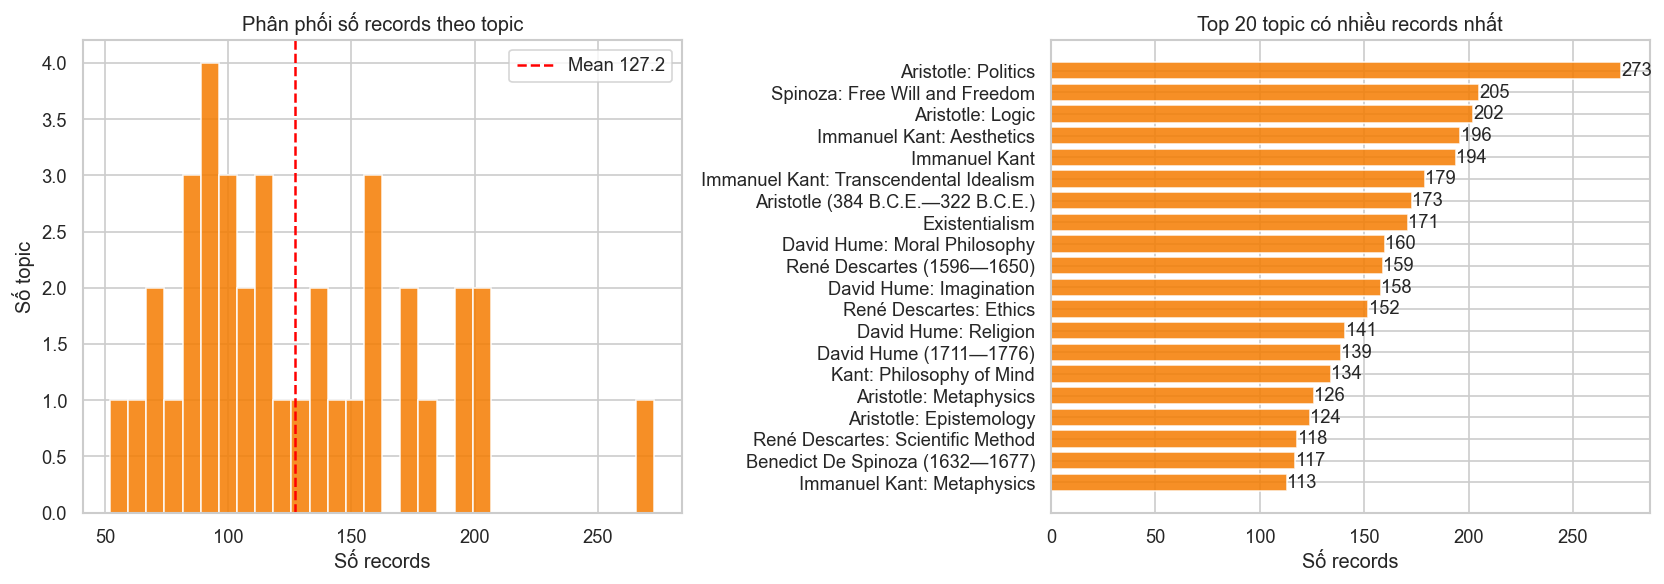


10 topic ít records nhất:
topic
Immanuel Kant: Philosophy of Religion        91
Theological Determinism                      89
Jean Paul Sartre: Existentialism             85
Aristotle: Motion                            84
René Descartes: The Mind-Body Distinction    83
Aristotle: Biology                           80
Benedict de Spinoza: Metaphysics             71
Sartre’s Political Philosophy                69
Benedict de Spinoza: Political Philosophy    65
Immanuel Kant: Radical Evil                  52


In [7]:
topic_counts = df['topic'].value_counts()

print(f'Số topic: {len(topic_counts)}')
print(f'Records/topic — min: {topic_counts.min()}, max: {topic_counts.max()}, mean: {topic_counts.mean():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram số records per topic
axes[0].hist(topic_counts.values, bins=30, color='#F57C00', edgecolor='white', alpha=0.85)
axes[0].axvline(topic_counts.mean(), color='red', linestyle='--',
                label=f'Mean {topic_counts.mean():.1f}')
axes[0].set_title('Phân phối số records theo topic')
axes[0].set_xlabel('Số records')
axes[0].set_ylabel('Số topic')
axes[0].legend()

# Top 20 topic nhiều records nhất
top20 = topic_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='#F57C00', alpha=0.85)
axes[1].set_title('Top 20 topic có nhiều records nhất')
axes[1].set_xlabel('Số records')
for i, v in enumerate(top20.values[::-1]):
    axes[1].text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

# Bottom 10
print('\n10 topic ít records nhất:')
print(topic_counts.tail(10).to_string())


## 6. Phát hiện bất thường

In [8]:
issues = {}

# 1. Bản dịch quá ngắn (< 20 từ) trong khi EN đủ dài
too_short = df[df['has_vi'] & (df['vi_words'] < 20) & (df['en_words'] >= 50)]
issues['VI quá ngắn (<20 từ)'] = len(too_short)

# 2. Tỉ lệ VI/EN bất thường (< 0.4 hoặc > 2.5)
bad_ratio = df[df['has_vi'] & ((df['ratio_words'] < 0.4) | (df['ratio_words'] > 2.5))]
issues['Tỉ lệ VI/EN bất thường'] = len(bad_ratio)

# 3. EN quá ngắn (< 50 từ — lọt qua chunking)
short_en = df[df['en_words'] < 50]
issues['EN < 50 từ'] = len(short_en)

# 4. EN quá dài (> 350 từ — chunking chưa tách hết)
long_en = df[df['en_words'] > 350]
issues['EN > 350 từ'] = len(long_en)

# 5. VI chứa ký tự tiếng Anh nhiều bất thường (nghi ngờ bỏ sót dịch)
import re
def latin_ratio(text):
    if not text:
        return 0
    latin = len(re.findall(r'[a-zA-Z]', text))
    return latin / max(len(text), 1)

df['vi_latin_ratio'] = df['vi'].apply(latin_ratio)
high_latin = df[df['has_vi'] & (df['vi_latin_ratio'] > 0.3)]
issues['VI nhiều ký tự Latin (>30%)'] = len(high_latin)

# Tóm tắt
print('=== Báo cáo bất thường ===')
for desc, count in issues.items():
    flag = '⚠️ ' if count > 0 else '✓  '
    print(f'  {flag}{desc}: {count:,} records')

# Hiển thị mẫu bất thường đáng chú ý
if len(too_short) > 0:
    print(f'\nMẫu VI quá ngắn (top 5):')
    display(too_short[['id','topic','en_words','vi_words','vi']].head())

if len(bad_ratio) > 0:
    print(f'\nMẫu tỉ lệ bất thường (top 5):')
    display(bad_ratio[['id','topic','en_words','vi_words','ratio_words']].head())


=== Báo cáo bất thường ===
  ✓  VI quá ngắn (<20 từ): 0 records
  ✓  Tỉ lệ VI/EN bất thường: 0 records
  ✓  EN < 50 từ: 0 records
  ✓  EN > 350 từ: 0 records
  ⚠️ VI nhiều ký tự Latin (>30%): 4,707 records


## 7. Scatter: độ dài EN vs VI

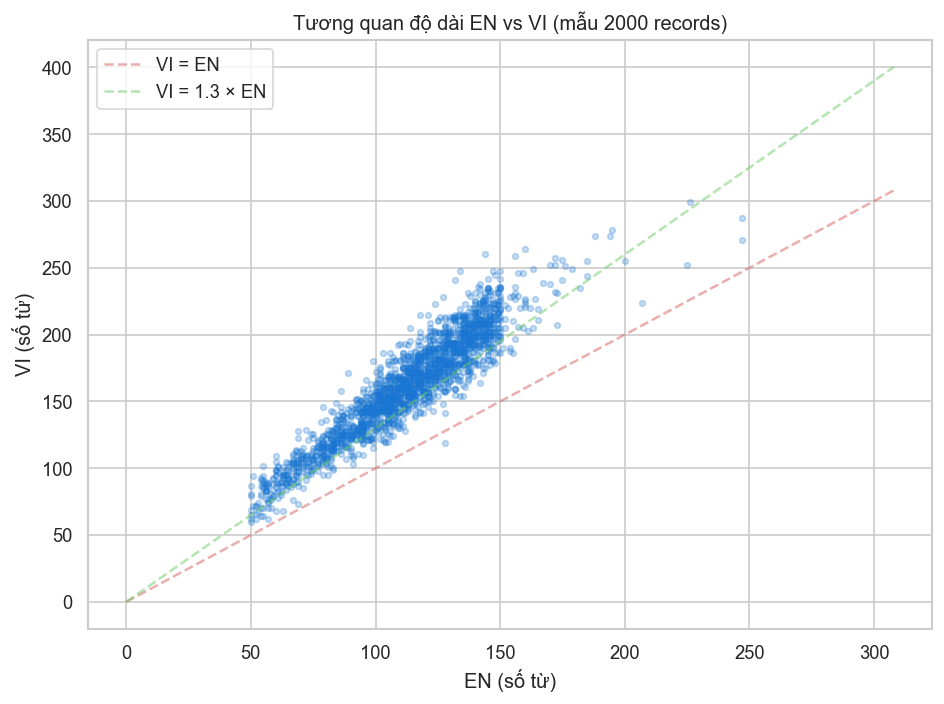

Hệ số tương quan Pearson (EN vs VI word count): 0.9302


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

sample = vi_df.sample(min(2000, len(vi_df)), random_state=42)
ax.scatter(sample['en_words'], sample['vi_words'],
           alpha=0.25, s=12, color='#1976D2')

# Đường tham chiếu y = x và y = 1.3x (tỉ lệ kỳ vọng VI dài hơn EN ~30%)
max_val = max(sample['en_words'].max(), sample['vi_words'].max())
x_line = range(0, int(max_val) + 10)
ax.plot(x_line, x_line,          'r--', alpha=0.5, label='VI = EN')
ax.plot(x_line, [v * 1.3 for v in x_line], 'g--', alpha=0.5, label='VI = 1.3 × EN')

ax.set_xlabel('EN (số từ)')
ax.set_ylabel('VI (số từ)')
ax.set_title('Tương quan độ dài EN vs VI (mẫu 2000 records)')
ax.legend()
plt.tight_layout()
plt.show()

corr = vi_df[['en_words','vi_words']].corr().iloc[0,1]
print(f'Hệ số tương quan Pearson (EN vs VI word count): {corr:.4f}')


## 8. Xem mẫu dữ liệu ngẫu nhiên

In [10]:
sample_records = df[df['has_vi']].sample(3, random_state=1)

for _, row in sample_records.iterrows():
    print(f"{'='*60}")
    print(f"ID     : {row['id']}")
    print(f"Topic  : {row['topic']}")
    print(f"EN ({row['en_words']} từ): {row['en'][:300]}{'...' if len(row['en']) > 300 else ''}")
    print(f"VI ({row['vi_words']} từ): {row['vi'][:300]}{'...' if len(row['vi']) > 300 else ''}")
    print()


ID     : 1519
Topic  : Immanuel Kant: Radical Evil
EN (67 từ): Once Kant is able to show how radical evil, as an innate condition, is possible the question becomes: How can evil, insofar as it rests on a propensity, constitute a genuine choice? In many ways, this question appears to be the essential problem for Kant’s ethics, since he believes that rational mor...
VI (105 từ): Một khi Kant đã có thể cho thấy cái ác triệt căn, với tư cách một điều kiện bẩm sinh, là khả hữu, câu hỏi đặt ra sẽ là: làm thế nào cái ác, trong chừng mực nó đặt nền trên một khuynh hướng, lại có thể cấu thành một sự lựa chọn đích thực? Trên nhiều phương diện, câu hỏi này dường như là vấn đề cốt yế...

ID     : 4216
Topic  : Aristotle: Politics
EN (161 từ): In Book IV Aristotle continues to think about existing regimes and their limitations, focusing on the question: what is the best possible regime? This is another aspect of political science that is still practiced today, as Aristotle combines a theory about h